In [1]:
import os, random, math, time, json, signal, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

os.environ['CUDA_LAUNCH_BLOCKING'] = "0"      # keep 0 in production; set 1 only when debugging CUDA errors

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# A100 TF32 – gives ~2× matmul throughput vs fp32 with negligible accuracy loss
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32        = True
torch.backends.cudnn.benchmark         = True   # auto-tune conv kernels

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    torch.cuda.empty_cache()

Device: cuda
  GPU : Tesla T4
  VRAM: 15.6 GB


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls /content/drive/MyDrive/dataset-NCKH-SignDETR-VSL/

dataset_combined.zip  datasetfilnal_v3.zip  final_dataset_vsl.zip
datasetfilnal_v2.zip  dataset.zip


In [4]:
# !rm -rf /content/SignDETR-VSL



In [5]:
import os
import shutil
import zipfile

# Khai báo các đường dẫn
source_path = '/content/drive/MyDrive/dataset-NCKH-SignDETR-VSL/datasetfilnal_v3.zip'
dest_zip = '/content/datasetfilnal_v3.zip'
extract_dir = '/content/SignDETR-VSL'

# 1. Kiểm tra xem thư mục đích đã tồn tại và có dữ liệu bên trong chưa
if os.path.exists(extract_dir) and len(os.listdir(extract_dir)) > 0:
    print("✅ Dataset đã được giải nén sẵn trong máy. Bỏ qua bước copy và unzip!")
else:
    print("⚠️ Chưa có dataset sẵn sàng. Bắt đầu xử lý...")

    # 2. Kiểm tra xem file zip đã được copy xuống Colab chưa
    if not os.path.exists(dest_zip):
        print("⏳ Đang copy file zip từ Google Drive xuống...")
        if os.path.exists(source_path):
            shutil.copy(source_path, dest_zip)
            print("✅ Copy từ Drive hoàn tất!")
        else:
            print("❌ LỖI: Không tìm thấy file zip trên Drive. Bạn đã mount Drive chưa?")
            raise FileNotFoundError("Không tìm thấy file trên Google Drive.")
    else:
        print("✅ File zip đã có sẵn ở '/content/'. Bỏ qua bước copy từ Drive.")

    # 3. Tiến hành giải nén
    print("⏳ Đang tiến hành giải nén...")
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(dest_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    print("🎉 Hoàn tất chuẩn bị dữ liệu!")

⚠️ Chưa có dataset sẵn sàng. Bắt đầu xử lý...
⏳ Đang copy file zip từ Google Drive xuống...
✅ Copy từ Drive hoàn tất!
⏳ Đang tiến hành giải nén...
🎉 Hoàn tất chuẩn bị dữ liệu!


In [6]:
import os

ROOT = "/content/SignDETR-VSL"
splits = ["train", "valid", "test"]

def count_files(path, exts):
    return len([f for f in os.listdir(path) if f.lower().endswith(exts)])

for split in splits:
    img_dir = f"{ROOT}/{split}/images"
    lbl_dir = f"{ROOT}/{split}/labels"

    n_imgs = count_files(img_dir, (".jpg", ".png", ".jpeg"))
    n_lbls = count_files(lbl_dir, (".txt",))

    print(f"{split.upper():5} | images: {n_imgs:5} | labels: {n_lbls:5}")


TRAIN | images:  2139 | labels:  2139
VALID | images:   616 | labels:   616
TEST  | images:   330 | labels:   330


In [7]:
def filename_set(path, ext):
    return set(os.path.splitext(f)[0] for f in os.listdir(path) if f.endswith(ext))

for split in splits:
    img_dir = f"{ROOT}/{split}/images"
    lbl_dir = f"{ROOT}/{split}/labels"

    imgs = filename_set(img_dir, ".jpg") | filename_set(img_dir, ".png")
    lbls = filename_set(lbl_dir, ".txt")

    missing_lbl = imgs - lbls
    missing_img = lbls - imgs

    print(f"\n[{split.upper()}]")
    print("Missing labels:", len(missing_lbl))
    print("Missing images:", len(missing_img))



[TRAIN]
Missing labels: 0
Missing images: 0

[VALID]
Missing labels: 0
Missing images: 0

[TEST]
Missing labels: 0
Missing images: 0


In [8]:
!find /content/SignDETR-VSL -maxdepth 2 -type d


/content/SignDETR-VSL
/content/SignDETR-VSL/train
/content/SignDETR-VSL/train/images
/content/SignDETR-VSL/train/labels
/content/SignDETR-VSL/valid
/content/SignDETR-VSL/valid/images
/content/SignDETR-VSL/valid/labels
/content/SignDETR-VSL/test
/content/SignDETR-VSL/test/images
/content/SignDETR-VSL/test/labels


In [9]:
def filename_set(path, ext):
    return set(os.path.splitext(f)[0] for f in os.listdir(path) if f.endswith(ext))

for split in splits:
    img_dir = f"{ROOT}/{split}/images"
    lbl_dir = f"{ROOT}/{split}/labels"

    imgs = filename_set(img_dir, ".jpg") | filename_set(img_dir, ".png")
    lbls = filename_set(lbl_dir, ".txt")

    missing_lbl = imgs - lbls
    missing_img = lbls - imgs

    print(f"\n[{split.upper()}]")
    print("Missing labels:", len(missing_lbl))
    print("Missing images:", len(missing_img))



[TRAIN]
Missing labels: 0
Missing images: 0

[VALID]
Missing labels: 0
Missing images: 0

[TEST]
Missing labels: 0
Missing images: 0


In [10]:
import os
import cv2
import matplotlib.pyplot as plt

LABEL_ID = 5  # đổi nhãn bạn muốn xem

IMG_DIR = "/content/SignDETR-VSL/train/images"
LBL_DIR = "/content/SignDETR-VSL/train/labels"

images_with_label = []

for lbl_file in os.listdir(LBL_DIR):
    lbl_path = os.path.join(LBL_DIR, lbl_file)
    with open(lbl_path, "r") as f:
        for line in f:
            if int(line.split()[0]) == LABEL_ID:
                img_name = lbl_file.replace(".txt", ".jpg")  # hoặc .png
                images_with_label.append(img_name)
                break

print(f"Tìm thấy {len(images_with_label)} ảnh có nhãn {LABEL_ID}")

Tìm thấy 97 ảnh có nhãn 5


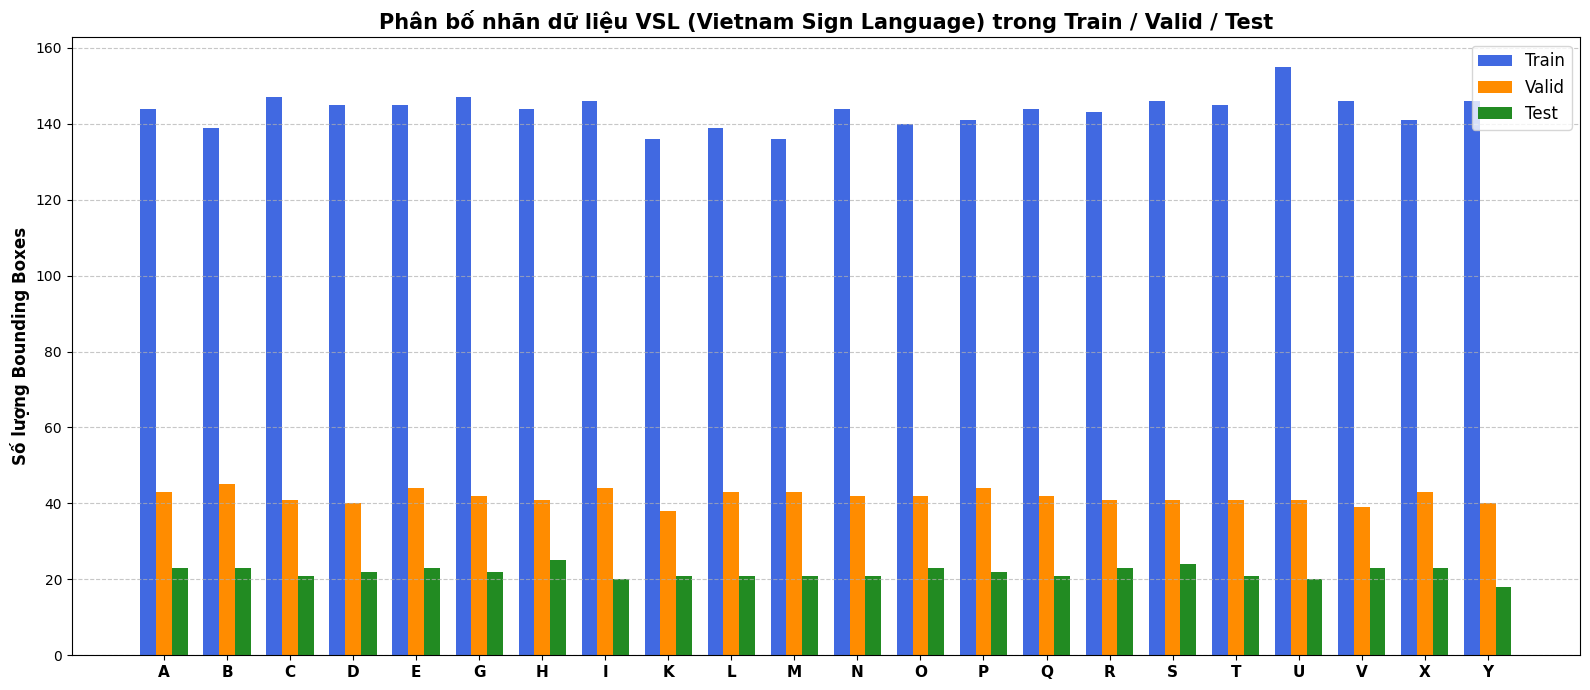


✅ Dataset sạch sẽ, không có ID nhãn nào vượt quá giới hạn 0-22.


In [11]:
import os
import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = "/content/SignDETR-VSL/"
splits = ['train', 'valid', 'test']
CLASSES = ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'X', 'Y']
# Khởi tạo dictionary để đếm số lượng bbox
counts = {split: {i: 0 for i in range(len(CLASSES))} for split in splits}
invalid_labels = []

# Quét file labels
for split in splits:
    lbl_dir = os.path.join(DATA_DIR, split, 'labels')
    if not os.path.exists(lbl_dir):
        continue

    for file in os.listdir(lbl_dir):
        if file.endswith('.txt'):
            with open(os.path.join(lbl_dir, file), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) > 0:
                        cls_id = int(parts[0])
                        # Nếu ID nằm trong danh sách chuẩn
                        if 0 <= cls_id < len(CLASSES):
                            counts[split][cls_id] += 1
                        else:
                            invalid_labels.append((split, file, cls_id))

# Vẽ biểu đồ
x = np.arange(len(CLASSES))
width = 0.25  # Độ rộng của mỗi cột

fig, ax = plt.subplots(figsize=(16, 7))

train_counts = [counts['train'][i] for i in range(len(CLASSES))]
valid_counts = [counts['valid'][i] for i in range(len(CLASSES))]
test_counts = [counts['test'][i] for i in range(len(CLASSES))]

# Tạo các cột
rects1 = ax.bar(x - width, train_counts, width, label='Train', color='royalblue')
rects2 = ax.bar(x, valid_counts, width, label='Valid', color='darkorange')
rects3 = ax.bar(x + width, test_counts, width, label='Test', color='forestgreen')

# Trang trí biểu đồ
ax.set_ylabel('Số lượng Bounding Boxes', fontsize=12, fontweight='bold')
ax.set_title('Phân bố nhãn dữ liệu VSL (Vietnam Sign Language) trong Train / Valid / Test', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, fontsize=11, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# In cảnh báo nếu có nhãn rác
if invalid_labels:
    print("\n⚠️ CẢNH BÁO: Phát hiện các nhãn rác (ID >= 23 hoặc < 0) trong Dataset!")
    print(f"Tổng số nhãn rác: {len(invalid_labels)}")
    print("5 ví dụ đầu tiên:", invalid_labels[:5])
else:
    print("\n✅ Dataset sạch sẽ, không có ID nhãn nào vượt quá giới hạn 0-22.")

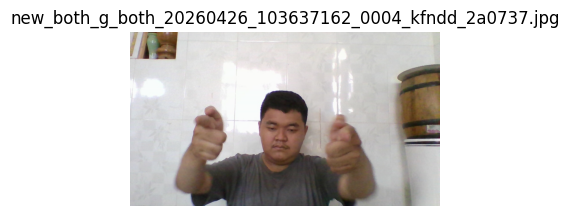

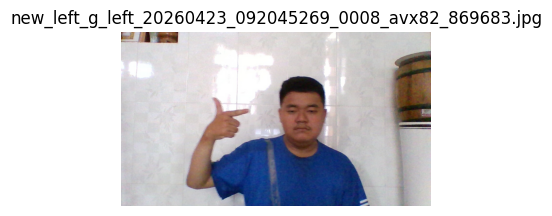

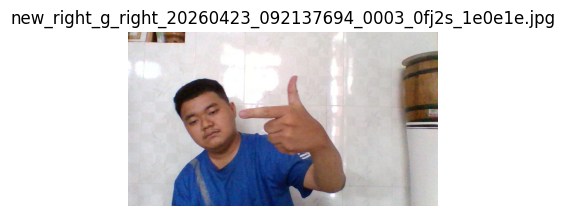

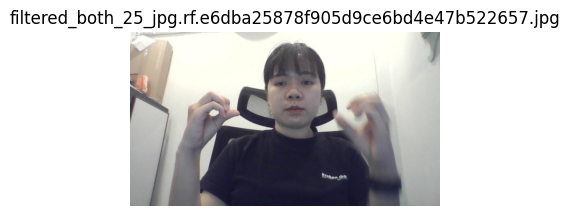

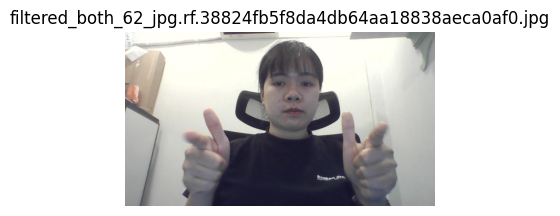

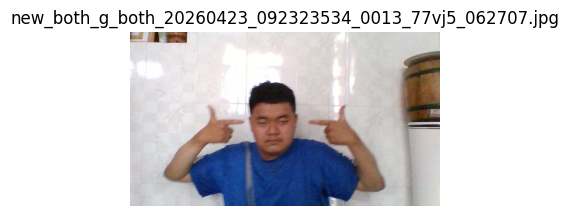

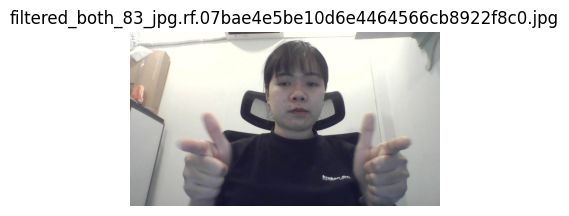

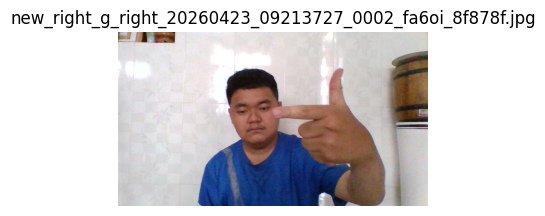

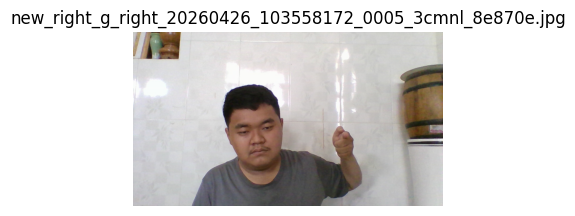

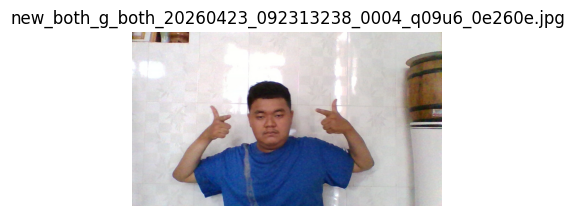

In [12]:
import os
import cv2
import matplotlib.pyplot as plt

for img_name in images_with_label[:10]:
    img_path = os.path.join(IMG_DIR, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)
    plt.show()

In [13]:
def draw_yolo_bbox(img, label_path):
    h, w, _ = img.shape
    with open(label_path, "r") as f:
        for line in f:
            cls, xc, yc, bw, bh = map(float, line.split())
            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)
            cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
    return img

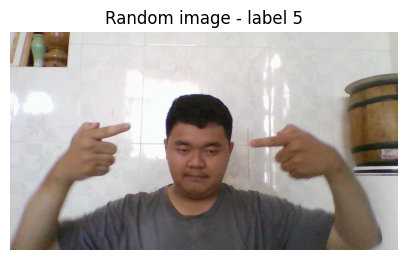

In [14]:
import random

random_img = random.choice(images_with_label)

img_path = os.path.join(IMG_DIR, random_img)
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title(f"Random image - label {LABEL_ID}")
plt.show()

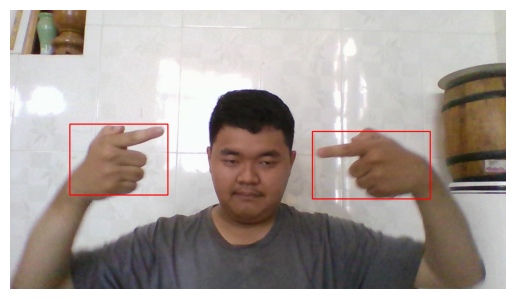

In [15]:
lbl_path = os.path.join(LBL_DIR, random_img.replace(".jpg", ".txt"))
img_box = draw_yolo_bbox(img.copy(), lbl_path)

plt.imshow(img_box)
plt.axis("off")
plt.show()

In [16]:
import subprocess, sys

for pkg in ['albumentations', 'colorama', 'rich', 'torchinfo', 'scipy']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

In [17]:
CLASSES = ['A','B','C','D','E','G','H','I','K','L',
           'M','N','O','P','Q','R','S','T','U','V','X','Y']
NUM_CLASSES = len(CLASSES)                       # 22
id2name = {i: n for i, n in enumerate(CLASSES)}
name2id = {n: i for i, n in enumerate(CLASSES)}

## mô hình DETR

In [18]:
def _get_1d_sincos_pos_embed(length, dim, temperature=10000.0, device=None):
    assert dim % 2 == 0
    pos  = torch.arange(length, device=device, dtype=torch.float32).unsqueeze(1)
    div  = torch.exp(torch.arange(0, dim, 2, device=device, dtype=torch.float32)
                     * (-math.log(temperature) / dim))
    pe   = torch.zeros(length, dim, device=device)
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe

def build_2d_sincos_pos_embed(H, W, dim, device=None):
    assert dim % 2 == 0
    d = dim // 2
    pe_y = _get_1d_sincos_pos_embed(H, d, device=device)  # (H, d)
    pe_x = _get_1d_sincos_pos_embed(W, d, device=device)  # (W, d)
    pos  = torch.zeros(H, W, dim, device=device)
    pos[:, :, :d] = pe_y[:, None, :].expand(-1, W, -1)
    pos[:, :, d:] = pe_x[None, :, :].expand(H, -1, -1)
    return pos.view(1, H * W, dim)                         # (1, HW, dim)

In [19]:
# 5. CUSTOM TRANSFORMER DECODER WITH INTERMEDIATE OUTPUTS
class TransformerDecoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.self_attn   = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.cross_attn  = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.ff1          = nn.Linear(d_model, dim_feedforward)
        self.ff2          = nn.Linear(dim_feedforward, d_model)
        self.norm1       = nn.LayerNorm(d_model)
        self.norm2       = nn.LayerNorm(d_model)
        self.norm3       = nn.LayerNorm(d_model)
        self.dropout     = nn.Dropout(dropout)
        self.act         = nn.GELU()

    def forward(self, tgt, memory, query_pos, pos):
        # self-attention on queries
        q = k = tgt + query_pos
        tgt2, _ = self.self_attn(q, k, tgt)
        tgt  = self.norm1(tgt + self.dropout(tgt2))
        # cross-attention to encoder memory
        tgt2, _ = self.cross_attn(tgt + query_pos, memory + pos, memory)
        tgt  = self.norm2(tgt + self.dropout(tgt2))
        # feed-forward
        tgt2 = self.ff2(self.dropout(self.act(self.ff1(tgt))))
        tgt  = self.norm3(tgt + self.dropout(tgt2))
        return tgt


class TransformerDecoder(nn.Module):
    """Returns a list of intermediate outputs (one per layer)."""
    def __init__(self, decoder_layer, num_layers):
        super().__init__()
        self.layers = nn.ModuleList([copy.deepcopy(decoder_layer) for _ in range(num_layers)])
        self.norm   = nn.LayerNorm(decoder_layer.ff2.out_features)

    def forward(self, tgt, memory, query_pos, pos):
        out, intermediates = tgt, []
        for layer in self.layers:
            out = layer(out, memory, query_pos, pos)
            intermediates.append(self.norm(out))
        return torch.stack(intermediates)               # (num_layers, B, Q, d)

In [20]:
# 6. DETR MODEL
from torchvision.models import resnet50, ResNet50_Weights

class DETR(nn.Module):
    def __init__(self,
                 num_classes,
                 hidden_dim       = 256,
                 nheads           = 8,
                 num_encoder_layers = 6,   # default: DETR-paper setting
                 num_decoder_layers = 6,
                 num_queries      = 25,
                 dim_feedforward  = 2048,
                 dropout          = 0.1):
        super().__init__()

        # ── Backbone
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        # keep only feature extractor, drop avg-pool + fc
        self.backbone = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4
        )

        # ── Projection: 2048 → hidden_dim
        self.input_proj = nn.Sequential(
            nn.Conv2d(2048, hidden_dim, 1),
            nn.GroupNorm(32, hidden_dim)               # more stable than BN under small batches
        )

        # ── Transformer encoder (standard PyTorch)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=nheads,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
            norm_first=True)                           # Pre-LN: faster convergence
        self.encoder = nn.TransformerEncoder(encoder_layer, num_encoder_layers,
                                              norm=nn.LayerNorm(hidden_dim))

        # ── Transformer decoder (custom, returns intermediates) ─
        dec_layer = TransformerDecoderLayer(hidden_dim, nheads, dim_feedforward, dropout)
        self.decoder = TransformerDecoder(dec_layer, num_decoder_layers)

        # ── Prediction heads (shared across layers via FFN) ────
        self.class_embed = nn.Linear(hidden_dim, num_classes + 1)
        self.bbox_embed  = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 4)
        )

        # ── Learnable query embeddings ─────────────────────────
        self.num_queries = num_queries
        self.query_embed = nn.Embedding(num_queries, hidden_dim)   # [Q, d]

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.input_proj[0].weight)
        nn.init.constant_(self.input_proj[0].bias, 0)
        nn.init.xavier_uniform_(self.class_embed.weight)
        nn.init.constant_(self.class_embed.bias, 0)
        for m in self.bbox_embed:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # ── 1. Backbone features ───────────────────────────────
        feat = self.backbone(x)                        # (B, 2048, H/32, W/32)
        feat = self.input_proj(feat)                   # (B, d, Hf, Wf)
        B, d, Hf, Wf = feat.shape

        # ── 2. Flatten + positional embedding ─────────────────
        src = feat.flatten(2).permute(0, 2, 1)         # (B, HW, d)
        pos = build_2d_sincos_pos_embed(Hf, Wf, d, device=feat.device)  # (1, HW, d)

        # ── 3. Encoder ─────────────────────────────────────────
        memory = self.encoder(src + pos)               # (B, HW, d)

        # ── 4. Decoder ─────────────────────────────────────────
        tgt        = torch.zeros(B, self.num_queries, d, device=x.device)
        query_pos  = self.query_embed.weight.unsqueeze(0).expand(B, -1, -1)  # (B, Q, d)

        # hs: (num_layers, B, Q, d)
        hs = self.decoder(tgt, memory, query_pos, pos)

        # ── 5. Prediction heads applied to ALL decoder layers ──
        outputs_class = self.class_embed(hs)           # (L, B, Q, num_cls+1)
        outputs_coord = self.bbox_embed(hs).sigmoid()  # (L, B, Q, 4)

        # Primary output = last decoder layer
        out = {
            'pred_logits': outputs_class[-1],
            'pred_boxes':  outputs_coord[-1],
        }

        # Auxiliary outputs (all other layers) for aux loss
        out['aux_outputs'] = [
            {'pred_logits': outputs_class[i], 'pred_boxes': outputs_coord[i]}
            for i in range(len(self.decoder.layers) - 1)
        ]
        return out


In [21]:
# 7. BOX UTILITIES
def box_cxcywh_to_xyxy(x):
    x0, y0, w, h = x.unbind(-1)
    return torch.stack([(x0 - .5*w), (y0 - .5*h), (x0 + .5*w), (y0 + .5*h)], -1)

def box_iou(boxes1, boxes2):
    area1 = (boxes1[:, 2]-boxes1[:, 0]).clamp(0) * (boxes1[:, 3]-boxes1[:, 1]).clamp(0)
    area2 = (boxes2[:, 2]-boxes2[:, 0]).clamp(0) * (boxes2[:, 3]-boxes2[:, 1]).clamp(0)
    lt    = torch.max(boxes1[:, None, :2], boxes2[:, :2])
    rb    = torch.min(boxes1[:, None, 2:], boxes2[:, 2:])
    wh    = (rb - lt).clamp(0)
    inter = wh[:, :, 0] * wh[:, :, 1]
    union = area1[:, None] + area2 - inter
    return inter / union.clamp(1e-6), union

def generalized_box_iou(boxes1, boxes2):
    iou, union = box_iou(boxes1, boxes2)
    lt  = torch.min(boxes1[:, None, :2], boxes2[:, :2])
    rb  = torch.max(boxes1[:, None, 2:], boxes2[:, 2:])
    wh  = (rb - lt).clamp(0)
    enc = wh[:, :, 0] * wh[:, :, 1]
    return iou - (enc - union) / enc.clamp(1e-6)

def stacker(batch):
    imgs, tgts = zip(*batch)
    return torch.stack(imgs), list(tgts)

In [22]:
# 8. HUNGARIAN MATCHER

from scipy.optimize import linear_sum_assignment

class HungarianMatcher(nn.Module):
    def __init__(self, cost_class=1.0, cost_bbox=5.0, cost_giou=2.0):
        super().__init__()
        self.cost_class = cost_class
        self.cost_bbox  = cost_bbox
        self.cost_giou  = cost_giou

    @torch.no_grad()
    def forward(self, outputs, targets):
        indices = []
        for i, tgt in enumerate(targets):
            logits = outputs['pred_logits'][i]
            boxes  = outputs['pred_boxes'][i]
            prob   = logits.softmax(-1)

            tgt_labels = tgt['labels'].long()
            tgt_boxes  = tgt['boxes'].float()

            C = (self.cost_bbox  * torch.cdist(boxes, tgt_boxes, p=1)
               + self.cost_class * -prob[:, tgt_labels]
               + self.cost_giou  * -generalized_box_iou(
                   box_cxcywh_to_xyxy(boxes),
                   box_cxcywh_to_xyxy(tgt_boxes)
               )).cpu()

            ii, jj = linear_sum_assignment(C)
            indices.append((torch.as_tensor(ii, dtype=torch.int64),
                            torch.as_tensor(jj, dtype=torch.int64)))
        return indices

In [23]:
# 9. DETR LOSS (with auxiliary decoder losses)
class DETRLoss(nn.Module):
    def __init__(self, num_classes, matcher, eos_coef=0.1,
                 cost_class=1.0, cost_bbox=5.0, cost_giou=2.0,
                 aux_loss_weight=0.5):
        super().__init__()
        self.num_classes      = num_classes
        self.matcher          = matcher
        self.eos_coef         = eos_coef
        self.cost_class       = cost_class
        self.cost_bbox        = cost_bbox
        self.cost_giou        = cost_giou
        self.aux_loss_weight  = aux_loss_weight

        empty_weight          = torch.ones(num_classes + 1)
        empty_weight[-1]      = eos_coef
        self.register_buffer('empty_weight', empty_weight)

    def _classification_loss(self, outputs, targets, indices):
        src_logits = outputs['pred_logits']
        idx = self._get_src_permutation_idx(indices)
        tgt_cls_o = torch.cat([t['labels'][J] for t, (_, J) in zip(targets, indices)])
        tgt_cls   = torch.full(src_logits.shape[:2], self.num_classes,
                               dtype=torch.int64, device=src_logits.device)
        tgt_cls[idx] = tgt_cls_o
        return F.cross_entropy(src_logits.transpose(1, 2), tgt_cls, self.empty_weight)

    def _box_loss(self, outputs, targets, indices, num_boxes):
        idx       = self._get_src_permutation_idx(indices)
        src_boxes = outputs['pred_boxes'][idx]
        tgt_boxes = torch.cat([t['boxes'][i] for t, (_, i) in zip(targets, indices)], 0)
        l1        = F.l1_loss(src_boxes, tgt_boxes, reduction='none').sum() / num_boxes
        giou      = (1 - torch.diag(generalized_box_iou(
                         box_cxcywh_to_xyxy(src_boxes),
                         box_cxcywh_to_xyxy(tgt_boxes)))).sum() / num_boxes
        return l1, giou

    def _get_src_permutation_idx(self, indices):
        batch_idx = torch.cat([torch.full_like(src, i) for i, (src, _) in enumerate(indices)])
        src_idx   = torch.cat([src for (src, _) in indices])
        return batch_idx, src_idx

    def _single_loss(self, outputs, targets):
        targets  = [{'labels': t['labels'].long(), 'boxes': t['boxes'].float()} for t in targets]
        indices  = self.matcher(outputs, targets)
        num_boxes = max(sum(len(t['labels']) for t in targets), 1)
        ce       = self._classification_loss(outputs, targets, indices)
        l1, giou = self._box_loss(outputs, targets, indices, num_boxes)
        return (self.cost_class * ce + self.cost_bbox * l1 + self.cost_giou * giou,
                ce, l1, giou)

    def forward(self, outputs, targets):
        total, ce, l1, giou = self._single_loss(outputs, targets)

        # Auxiliary losses from intermediate decoder layers
        aux_total = 0.0
        for aux_out in outputs.get('aux_outputs', []):
            a, _, _, _ = self._single_loss(aux_out, targets)
            aux_total += a
        if outputs.get('aux_outputs'):
            aux_total /= len(outputs['aux_outputs'])

        loss = total + self.aux_loss_weight * aux_total
        return loss, ce, l1, giou

In [24]:
# 10. DATASET
import glob
from torch.utils.data import Dataset
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

class DETRData(Dataset):
    def __init__(self, path, train=True):
        self.images_path = os.path.join(path, 'images')
        self.labels_path = os.path.join(path, 'labels')
        self.train = train
        self.labels = [f for f in os.listdir(self.labels_path) if f.endswith('.txt')]

    # ── Augmentation pipelines ────────────────────────────────
    def _build_train_transform(self):
        return A.Compose([
            A.LongestMaxSize(max_size=800),
            A.PadIfNeeded(800, 800, border_mode=cv2.BORDER_CONSTANT, fill=(0, 0, 0)),
            A.RandomSizedBBoxSafeCrop(512, 512, erosion_rate=0.0, p=0.7),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.4),
            A.MotionBlur(blur_limit=3, p=0.2),
            A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.5),
            A.Resize(512, 512),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'],
                                    min_visibility=0.3))

    def _build_val_transform(self):
        return A.Compose([
            A.LongestMaxSize(max_size=512),
            A.PadIfNeeded(512, 512, border_mode=cv2.BORDER_CONSTANT, fill=(0, 0, 0)),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        lbl_file = self.labels[idx]
        lbl_path = os.path.join(self.labels_path, lbl_file)
        base     = os.path.splitext(lbl_file)[0]

        matches = glob.glob(os.path.join(self.images_path, base + '.*'))
        if not matches:
            return self.__getitem__((idx + 1) % len(self))

        try:
            img = np.array(Image.open(matches[0]).convert('RGB'))
            bboxes, cls_ids = [], []

            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5: continue
                    c = int(parts[0])
                    x, y, w, h = [float(v) for v in parts[1:5]]
                    x, y, w, h = (np.clip(v, 0., 1.) for v in (x, y, w, h))
                    if w > 1e-3 and h > 1e-3:
                        bboxes.append([x, y, w, h])
                        cls_ids.append(c)

            if not cls_ids:
                return self.__getitem__((idx + 1) % len(self))

            transform = self._build_train_transform() if self.train else self._build_val_transform()

            for _ in range(20):
                try:
                    aug = transform(image=img, bboxes=bboxes, class_labels=cls_ids)
                    if aug['bboxes']:
                        break
                except Exception:
                    continue
            else:
                aug = self._build_val_transform()(image=img, bboxes=bboxes, class_labels=cls_ids)

            if not aug['bboxes']:
                return self.__getitem__((idx + 1) % len(self))

            return (aug['image'],
                    {'labels': torch.tensor(aug['class_labels'], dtype=torch.long),
                     'boxes':  torch.tensor(aug['bboxes'], dtype=torch.float32)})

        except Exception as e:
            print(f"Skip {lbl_file}: {e}")
            return self.__getitem__((idx + 1) % len(self))


In [25]:
# 11. DATA LOADERS
DATA_DIR   = "/content/SignDETR-VSL/"
BATCH_SIZE = 32          # A100 80GB → safe to use 32–64 for 512×512 input
NUM_WORKERS = 12

train_ds = DETRData(os.path.join(DATA_DIR, 'train'), train=True)
valid_ds = DETRData(os.path.join(DATA_DIR, 'valid'), train=False)
test_ds  = DETRData(os.path.join(DATA_DIR, 'test'),  train=False)

train_dl = torch.utils.data.DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    collate_fn=stacker, drop_last=True, prefetch_factor=2, persistent_workers=True)

valid_dl = torch.utils.data.DataLoader(
    valid_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
    collate_fn=stacker, drop_last=False, prefetch_factor=2, persistent_workers=True)

test_dl = torch.utils.data.DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, collate_fn=stacker, drop_last=False)

print(f"Train: {len(train_ds)}  Valid: {len(valid_ds)}  Test: {len(test_ds)}")

Train: 2139  Valid: 616  Test: 330


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## load dataset

In [30]:
# 12. MODEL + OPTIMISER + LOSS + SCHEDULER
NUM_EPOCHS      = 100
LR_BACKBONE     = 1e-5
LR_TRANSFORMER  = 1e-4
WEIGHT_DECAY    = 1e-4
WARMUP_EPOCHS   = 10
EMA_START_EPOCH = 10
HIDDEN_DIM      = 256
NHEADS          = 8
ENC_LAYERS      = 6
DEC_LAYERS      = 6
NUM_QUERIES     = 25
DIM_FF          = 2048
DROPOUT         = 0.1

model = DETR(num_classes=NUM_CLASSES,
             hidden_dim=HIDDEN_DIM,
             nheads=NHEADS,
             num_encoder_layers=ENC_LAYERS,
             num_decoder_layers=DEC_LAYERS,
             num_queries=NUM_QUERIES,
             dim_feedforward=DIM_FF,
             dropout=DROPOUT).to(device)



# ── Parameter groups (backbone gets lower LR)
backbone_params    = [p for n, p in model.named_parameters()
                      if 'backbone' in n and p.requires_grad]
non_backbone_params = [p for n, p in model.named_parameters()
                       if 'backbone' not in n and p.requires_grad]

optimizer = torch.optim.AdamW(
    [{'params': backbone_params,     'lr': LR_BACKBONE},
     {'params': non_backbone_params, 'lr': LR_TRANSFORMER}],
    weight_decay=WEIGHT_DECAY)

# ── EMA (eval weights track a smoothed version of model weights)
class ModelEMA:
    def __init__(self, model, decay=0.999):   # 0.9999 → 0.999
        self.model = copy.deepcopy(model).eval()
        self.decay = decay

    @torch.no_grad()
    def update(self, model):
        for ema_p, m_p in zip(self.model.parameters(), model.parameters()):
            ema_p.mul_(self.decay).add_(m_p.data, alpha=1 - self.decay)

ema = ModelEMA(model, decay=0.999)
# torch.compile speeds up by 10-30% on A100 (requires PyTorch >= 2.0)
try:
    model = torch.compile(model)
    print("torch.compile: enabled")
except Exception:
    print("torch.compile: not available (needs PyTorch >= 2.0)")
# ── Cosine LR scheduler with linear warmup
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS          # linear warmup
    progress = (epoch - WARMUP_EPOCHS) / max(NUM_EPOCHS - WARMUP_EPOCHS, 1)
    return 0.5 * (1 + math.cos(math.pi * progress)) # cosine decay

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ── Loss
matcher   = HungarianMatcher(cost_class=1.0, cost_bbox=5.0, cost_giou=2.0)
criterion = DETRLoss(NUM_CLASSES, matcher, eos_coef=0.1,
                     cost_class=1.0, cost_bbox=5.0, cost_giou=2.0,
                     aux_loss_weight=0.5).to(device)

# ── AMP GradScaler (fp16 mixed precision)
scaler = torch.amp.GradScaler('cuda')

print(f"Params total: {sum(p.numel() for p in model.parameters()):,}")
print(f"Params train: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


/tmp/ipykernel_2626/574338059.py:36: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_encoder_layers,


torch.compile: enabled
Params total: 41,541,979
Params train: 41,541,979


In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import numpy as np

def visualize_augmented_data(dataset, num_samples=4):
    """
    Hàm chọn ngẫu nhiên các ảnh từ dataset, giải chuẩn hóa và vẽ bounding box.
    """
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))

    classes = "A B C D E G H I K L M N O P Q R S T U V X Y".split()

    for i in range(num_samples):
        # 1. Chọn ngẫu nhiên 1 file trong tập dữ liệu
        idx = random.randint(0, len(dataset) - 1)
        img_tensor, target = dataset[idx]

        # 2. Giải chuẩn hóa ảnh (Un-normalize)
        # Vì ảnh đã trừ mean và chia std ở bước transform, giờ ta làm ngược lại
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])

        # Pytorch dùng (Channel, Height, Width), Matplotlib cần (Height, Width, Channel)
        img = img_tensor.permute(1, 2, 0).numpy()
        img = std * img + mean
        img = np.clip(img, 0, 1) # Giới hạn pixel trong khoảng [0, 1] để vẽ

        ax = axes[i]
        ax.imshow(img)
        ax.axis('off')

        # 3. Vẽ Bounding Box (Đang ở định dạng YOLO: x_center, y_center, width, height)
        h, w, _ = img.shape
        boxes = target['boxes'].numpy()
        labels = target['labels'].numpy()

        for box, label_id in zip(boxes, labels):
            x_c, y_c, box_w, box_h = box

            # Chuyển từ tỷ lệ 0-1 sang tọa độ pixel thực tế trên ảnh
            xmin = (x_c - box_w / 2) * w
            ymin = (y_c - box_h / 2) * h
            rect_w = box_w * w
            rect_h = box_h * h

            # Vẽ khung chữ nhật màu xanh lá hoặc đỏ cho nổi bật
            rect = patches.Rectangle(
                (xmin, ymin), rect_w, rect_h,
                linewidth=2, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)

            # Ghi tên chữ cái ký hiệu lên góc trên của box
            class_name = classes[label_id] if label_id < len(classes) else str(label_id)
            ax.text(
                xmin, ymin - 8, class_name,
                color='white', fontsize=12, weight='bold',
                backgroundcolor='lime'
            )

    plt.tight_layout()
    plt.show()

# --- CÁCH SỬ DỤNG ---
# Giả sử bạn khởi tạo dataset như thế này:
# my_dataset = DETRData(path='/content/SignDETR-VSL/final_dataset_vsl', train=True)

# Gọi hàm để xem thử 4 ảnh ngẫu nhiên
#

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


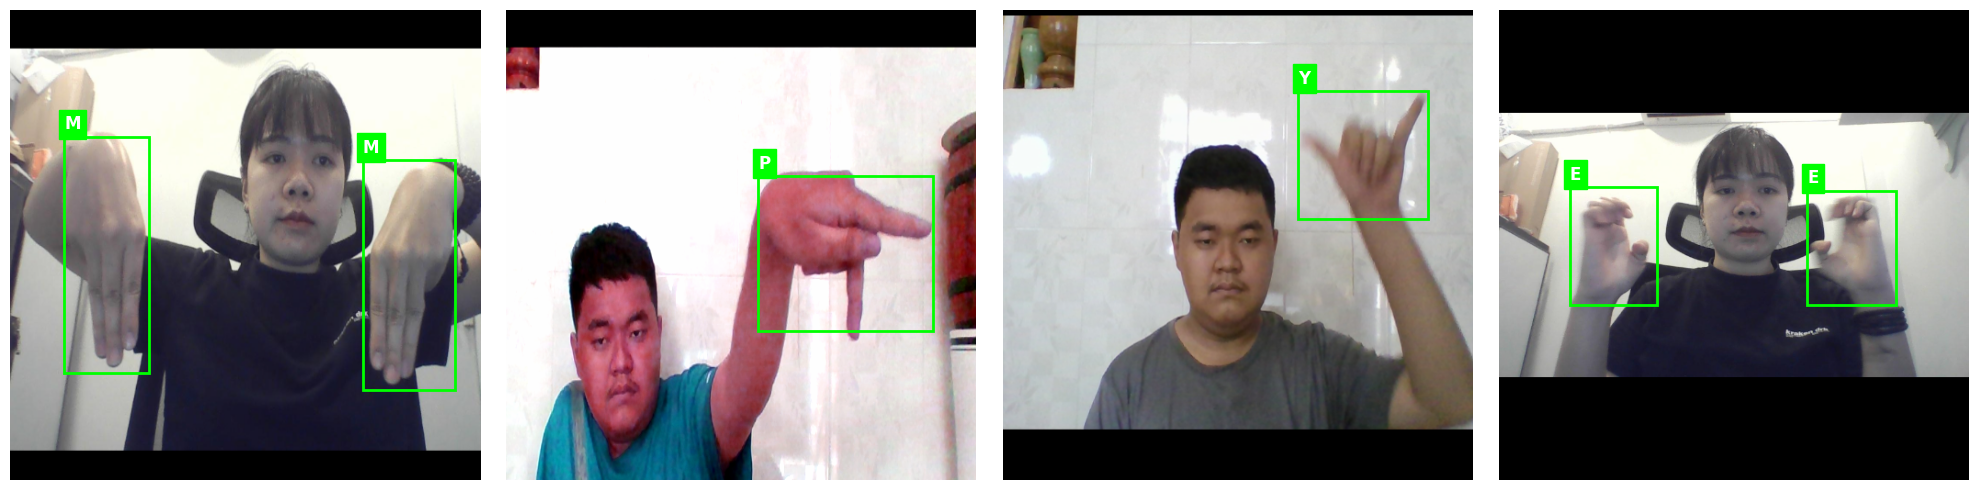

In [28]:
visualize_augmented_data(train_ds, num_samples=4)

##Training

In [29]:
# 13. TRAINING & EVALUATION LOOPS
from tqdm import tqdm

def train_one_epoch(model, dl, criterion, optimizer, scaler, device):
    model.train()
    tot = ce_tot = l1_tot = giou_tot = 0.0

    for imgs, tgts in tqdm(dl, desc="Train", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        tgts = [{k: v.to(device, non_blocking=True) for k, v in t.items()} for t in tgts]

        with torch.amp.autocast('cuda'):              # fp16 forward
            outs = model(imgs)
            loss, ce, l1, giou = criterion(outs, tgts)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)       # faster than zero_grad()

        ema.update(model)

        tot      += loss.item()
        ce_tot   += ce.item()
        l1_tot   += l1.item()
        giou_tot += giou.item()

    n = len(dl)
    return dict(total=tot/n, ce=ce_tot/n, bbox=l1_tot/n, giou=giou_tot/n)


@torch.no_grad()
def evaluate(model, dl, criterion, device):
    model.eval()
    tot = ce_tot = l1_tot = giou_tot = 0.0

    for imgs, tgts in tqdm(dl, desc="Valid", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        tgts = [{k: v.to(device, non_blocking=True) for k, v in t.items()} for t in tgts]

        with torch.amp.autocast('cuda'):
            outs = model(imgs)
            loss, ce, l1, giou = criterion(outs, tgts)

        tot += loss.item(); ce_tot += ce.item()
        l1_tot += l1.item(); giou_tot += giou.item()

    n = len(dl)
    return dict(total=tot/n, ce=ce_tot/n, bbox=l1_tot/n, giou=giou_tot/n)

In [30]:
print(f"Train: {len(train_ds)} samples, {len(train_dl)} batches")
print(f"Valid: {len(valid_ds)} samples, {len(valid_dl)} batches")
print(f"Test : {len(test_ds)}  samples, {len(test_dl)}  batches")

# Kiểm tra tỉ lệ train/val
print(f"\nTỉ lệ Train/Valid: {len(train_ds)/len(valid_ds):.1f}x")

Train: 2139 samples, 66 batches
Valid: 616 samples, 20 batches
Test : 330  samples, 11  batches

Tỉ lệ Train/Valid: 3.5x


In [31]:
# 14. TRAINING LOOP
OUTPUT_DIR = '/content/drive/MyDrive/NCKH_SignDETR_VSL/v3/resnet/base/output/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

best_model_path = os.path.join(OUTPUT_DIR, 'best_signdetr_model.pth')
history_path    = os.path.join(OUTPUT_DIR, 'training_history.json')
log_path        = os.path.join(OUTPUT_DIR, 'training_log.txt')

history      = {k: [] for k in ['train_loss','val_loss','train_ce','val_ce',
                                  'train_bbox','val_bbox','train_giou','val_giou','lr']}
best_val     = float('inf')
SAVE_FREQ    = 5

def log(msg):
    print(msg)
    with open(log_path, 'a') as f:
        f.write(msg + '\n')

log(f"Training start | ENC={ENC_LAYERS} DEC={DEC_LAYERS} Q={NUM_QUERIES} BS={BATCH_SIZE}")

for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    tr = train_one_epoch(model, train_dl, criterion, optimizer, scaler, device)

    eval_model = ema.model if epoch >= EMA_START_EPOCH else model
    vl = evaluate(eval_model, valid_dl, criterion, device)
    scheduler.step()
    lr = optimizer.param_groups[0]['lr']

    for k, v in [('train_loss', tr['total']), ('val_loss',  vl['total']),
                  ('train_ce',  tr['ce']),    ('val_ce',    vl['ce']),
                  ('train_bbox',tr['bbox']),  ('val_bbox',  vl['bbox']),
                  ('train_giou',tr['giou']),  ('val_giou',  vl['giou']),
                  ('lr', lr)]:
        history[k].append(v)

    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)

    note = ''
    if vl['total'] < best_val:
        best_val = vl['total']
        torch.save({'epoch': epoch,
                    'model_state_dict': eval_model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': best_val}, best_model_path)
        note += ' [BEST]'

    if (epoch + 1) % SAVE_FREQ == 0 or epoch == NUM_EPOCHS - 1:
        ckpt = os.path.join(OUTPUT_DIR, f'checkpoint_epoch_{epoch+1:03d}.pth')
        torch.save({'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'loss': vl['total']}, ckpt)
        note += f' [CKP ep{epoch+1}]'

    log(f"Ep {epoch+1:03d}/{NUM_EPOCHS} | {time.time()-t0:.0f}s | LR={lr:.2e}")
    log(f"  Train: {tr['total']:.4f} (CE={tr['ce']:.4f} BBox={tr['bbox']:.4f} GIoU={tr['giou']:.4f})")
    log(f"  Valid: {vl['total']:.4f} (CE={vl['ce']:.4f} BBox={vl['bbox']:.4f} GIoU={vl['giou']:.4f}){note}")

log("Training complete.")

Training start | ENC=6 DEC=6 Q=25 BS=32


Ep 001/100 | 243s | LR=2.00e-06
  Train: 9.2270 (CE=2.1392 BBox=0.4119 GIoU=0.9837)
  Valid: 8.7970 (CE=1.8917 BBox=0.3702 GIoU=1.0490) [BEST]


Ep 002/100 | 38s | LR=3.00e-06
  Train: 7.6496 (CE=1.9093 BBox=0.3151 GIoU=0.8285)
  Valid: 9.3225 (CE=1.8905 BBox=0.3746 GIoU=1.2636)


Ep 003/100 | 39s | LR=4.00e-06
  Train: 6.3912 (CE=1.9015 BBox=0.2294 GIoU=0.6089)
  Valid: 8.7828 (CE=1.8709 BBox=0.3685 GIoU=1.0680) [BEST]


Ep 004/100 | 38s | LR=5.00e-06
  Train: 6.1359 (CE=1.8871 BBox=0.2153 GIoU=0.5629)
  Valid: 8.8859 (CE=1.8624 BBox=0.3829 GIoU=1.1055)


...

Ep 096/100 | 38s | LR=4.87e-08
  Train: 0.8159 (CE=0.0308 BBox=0.0422 GIoU=0.1388)
  Valid: 2.3472 (CE=0.5064 BBox=0.0743 GIoU=0.3050)


Ep 097/100 | 38s | LR=2.74e-08
  Train: 0.8140 (CE=0.0355 BBox=0.0414 GIoU=0.1377)
  Valid: 2.3484 (CE=0.5074 BBox=0.0743 GIoU=0.3051)


Ep 098/100 | 37s | LR=1.22e-08
  Train: 0.8210 (CE=0.0389 BBox=0.0418 GIoU=0.1377)
  Valid: 2.3490 (CE=0.5064 BBox=0.0743 GIoU=0.3050)


Ep 099/100 | 37s | LR=3.05e-09
  Train: 0.8175 (CE=0.0327 BBox=0.0422 GIoU=0.1384)
  Valid: 2.3499 (CE=0.5073 BBox=0.0743 GIoU=0.3050)


Ep 100/100 | 37s | LR=0.00e+00
  Train: 0.8127 (CE=0.0349 BBox=0.0414 GIoU=0.1370)
  Valid: 2.3523 (CE=0.5087 BBox=0.0743 GIoU=0.3048) [CKP ep100]
Training complete.


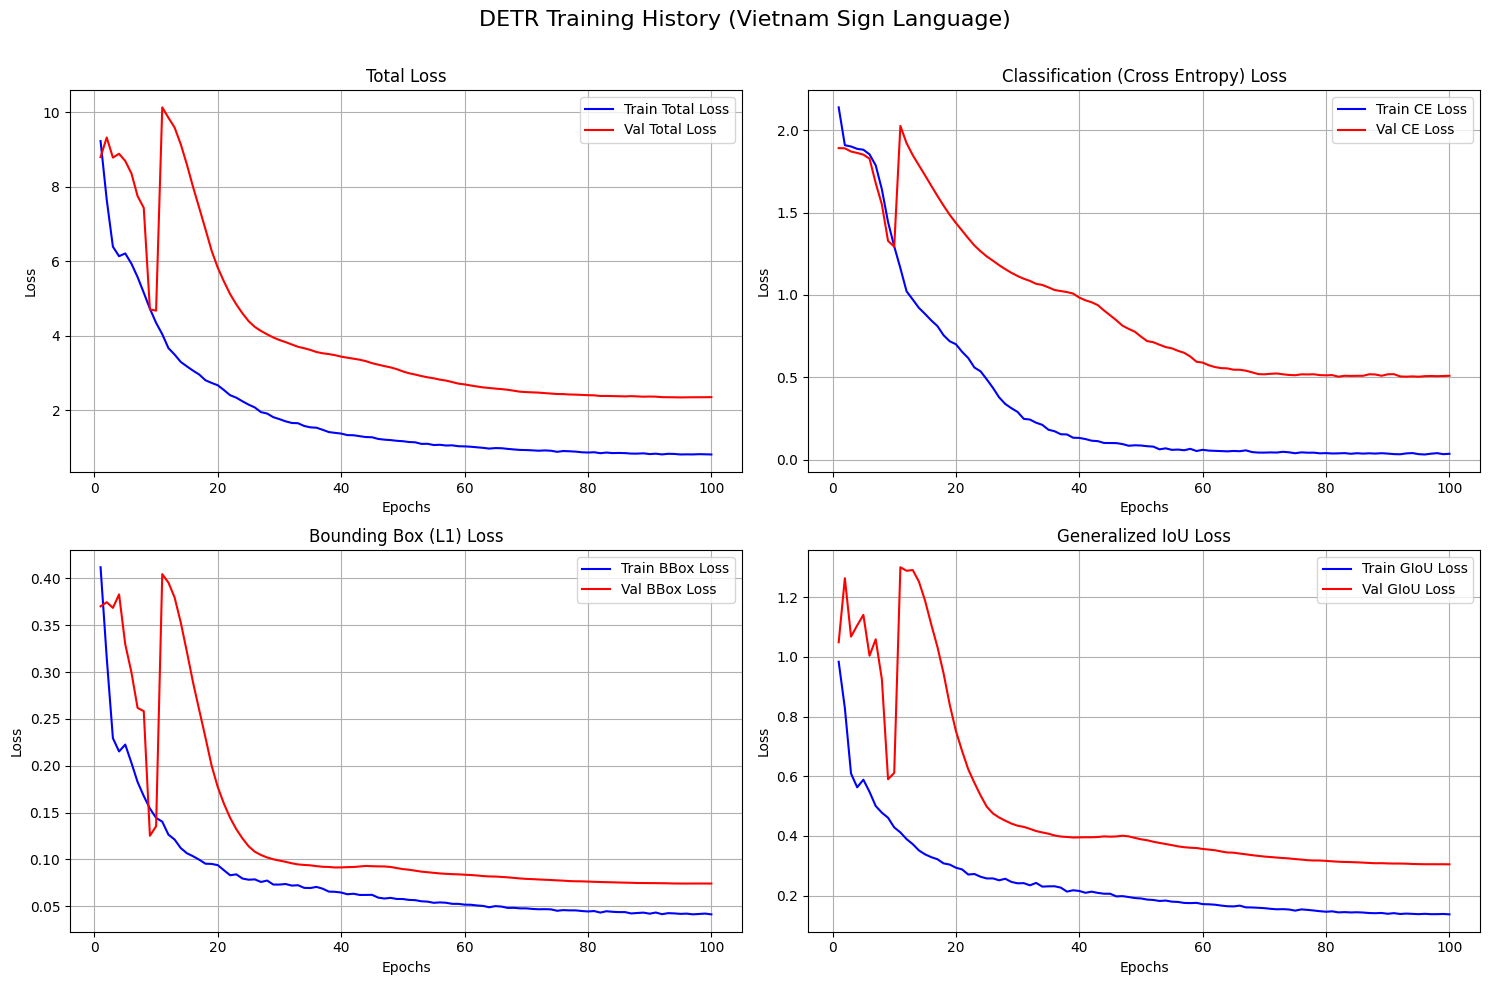

In [32]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('DETR Training History (Vietnam Sign Language)', fontsize=16)

    # 1. Total Loss
    axs[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Total Loss')
    axs[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Total Loss')
    axs[0, 0].set_title('Total Loss')
    axs[0, 0].set_xlabel('Epochs')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # 2. Classification Loss
    axs[0, 1].plot(epochs, history['train_ce'], 'b-', label='Train CE Loss')
    axs[0, 1].plot(epochs, history['val_ce'], 'r-', label='Val CE Loss')
    axs[0, 1].set_title('Classification (Cross Entropy) Loss')
    axs[0, 1].set_xlabel('Epochs')
    axs[0, 1].set_ylabel('Loss')
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # 3. Bounding Box L1 Loss
    axs[1, 0].plot(epochs, history['train_bbox'], 'b-', label='Train BBox Loss')
    axs[1, 0].plot(epochs, history['val_bbox'], 'r-', label='Val BBox Loss')
    axs[1, 0].set_title('Bounding Box (L1) Loss')
    axs[1, 0].set_xlabel('Epochs')
    axs[1, 0].set_ylabel('Loss')
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    # 4. GIoU Loss
    axs[1, 1].plot(epochs, history['train_giou'], 'b-', label='Train GIoU Loss')
    axs[1, 1].plot(epochs, history['val_giou'], 'r-', label='Val GIoU Loss')
    axs[1, 1].set_title('Generalized IoU Loss')
    axs[1, 1].set_xlabel('Epochs')
    axs[1, 1].set_ylabel('Loss')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

# Gọi hàm để vẽ biểu đồ
plot_training_history(history)

In [33]:

# test_dataloader = DataLoader(
#     test_dataset,
#     batch_size=8,
#     collate_fn=stacker,
#     drop_last=False
# ) test_dl


In [31]:
MODEL_PATH = "/content/drive/MyDrive/NCKH_SignDETR_VSL/v3/resnet/base/output/best_signdetr_model.pth"


In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DETR(num_classes=22)
checkpoint = torch.load(MODEL_PATH)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)
model.to(device)

model.eval()



print("Mô hình đã sẵn sàng.")

/tmp/ipykernel_2626/574338059.py:36: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_encoder_layers,


Mô hình đã sẵn sàng.


In [33]:

import torch
import torch.nn.functional as F
from tqdm import tqdm
import time
@torch.no_grad()
def calculate_accuracy_and_deviation(
    model,
    dataloader,
    matcher,
    device,
    topk=3,
    conf_threshold=0.35,
    iou_threshold=0.5,
):
    model.eval()

    total_matched_objects = 0
    correct_top1_predictions = 0
    correct_topk_predictions = 0
    confident_objects = 0
    confident_correct_top1 = 0
    confidence_sum = 0.0

    iou_sum = 0.0
    iou_pass_count = 0

    total_box_deviation = 0.0

    # Biến để lưu sai số riêng cho từng thành phần (Tùy chọn xem chi tiết)
    dev_cx, dev_cy, dev_w, dev_h = 0.0, 0.0, 0.0, 0.0

    num_classes = None
    class_total = None
    class_correct = None

    pbar = tqdm(dataloader, desc="Calculating Accuracy & Deviation")
    for images, targets in pbar:
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # 1. Chạy model để lấy dự đoán
        outputs = model(images)

        # 2. Dùng HungarianMatcher để tìm ra các dự đoán khớp với Ground Truth nhất
        indices = matcher(outputs, targets)

        if num_classes is None:
            # outputs['pred_logits'] includes no-object at the last index
            num_classes = outputs['pred_logits'].shape[-1] - 1
            class_total = [0 for _ in range(num_classes)]
            class_correct = [0 for _ in range(num_classes)]

        for batch_idx, (pred_idx, tgt_idx) in enumerate(indices):
            # Lấy ra các dự đoán và đáp án đã được ghép cặp (matched)
            pred_logits_matched = outputs['pred_logits'][batch_idx, pred_idx]
            pred_boxes_matched = outputs['pred_boxes'][batch_idx, pred_idx]

            tgt_labels_matched = targets[batch_idx]['labels'][tgt_idx]
            tgt_boxes_matched = targets[batch_idx]['boxes'][tgt_idx]

            num_objects = len(tgt_labels_matched)
            if num_objects == 0:
                continue

            total_matched_objects += num_objects

            # --- TÍNH ACCURACY (Top-1, Top-k, confidence threshold) ---
            class_probs = pred_logits_matched.softmax(dim=-1)[:, :-1]  # drop no-object class
            conf_scores, pred_labels = class_probs.max(dim=-1)

            k_val = min(topk, class_probs.shape[-1])
            topk_labels = class_probs.topk(k=k_val, dim=-1).indices

            is_top1_correct = pred_labels == tgt_labels_matched
            is_topk_correct = (topk_labels == tgt_labels_matched.unsqueeze(1)).any(dim=1)
            confident_mask = conf_scores >= conf_threshold

            correct_top1_predictions += is_top1_correct.sum().item()
            correct_topk_predictions += is_topk_correct.sum().item()
            confident_objects += confident_mask.sum().item()
            confident_correct_top1 += (is_top1_correct & confident_mask).sum().item()
            confidence_sum += conf_scores.sum().item()

            for gt_label, is_correct in zip(tgt_labels_matched, is_top1_correct):
                gt_id = int(gt_label.item())
                if 0 <= gt_id < num_classes:
                    class_total[gt_id] += 1
                    if bool(is_correct.item()):
                        class_correct[gt_id] += 1

            # --- TÍNH mIoU + tỉ lệ IoU đạt ngưỡng ---
            pred_xyxy = box_cxcywh_to_xyxy(pred_boxes_matched)
            tgt_xyxy = box_cxcywh_to_xyxy(tgt_boxes_matched)
            iou_matrix, _ = box_iou(pred_xyxy, tgt_xyxy)
            matched_iou = torch.diag(iou_matrix)
            iou_sum += matched_iou.sum().item()
            iou_pass_count += (matched_iou >= iou_threshold).sum().item()

            # --- TÍNH ĐỘ LỆCH (Box Deviation - L1 Error) ---
            # Tính sai số tuyệt đối trung bình cho 4 tọa độ (cx, cy, w, h)
            # Tọa độ đang ở dạng chuẩn hóa (0 -> 1)
            deviation = F.l1_loss(pred_boxes_matched, tgt_boxes_matched, reduction='sum').item()
            total_box_deviation += deviation

            # Tính sai số chi tiết cho tâm (cx, cy) và kích thước (w, h)
            abs_diff = torch.abs(pred_boxes_matched - tgt_boxes_matched)
            dev_cx += abs_diff[:, 0].sum().item()
            dev_cy += abs_diff[:, 1].sum().item()
            dev_w  += abs_diff[:, 2].sum().item()
            dev_h  += abs_diff[:, 3].sum().item()

    # Tổng hợp kết quả
    if total_matched_objects == 0:
        print("Không tìm thấy đối tượng nào trong tập test!")
        return {}

    top1_accuracy = (correct_top1_predictions / total_matched_objects) * 100
    topk_accuracy = (correct_topk_predictions / total_matched_objects) * 100
    confident_accuracy = (
        (confident_correct_top1 / confident_objects) * 100 if confident_objects > 0 else 0.0
    )
    avg_confidence = confidence_sum / total_matched_objects
    mean_iou = iou_sum / total_matched_objects
    iou_pass_rate = (iou_pass_count / total_matched_objects) * 100

    # Chia cho (số object * 4 tọa độ) để ra độ lệch trung bình trên mỗi trục tọa độ
    avg_deviation = total_box_deviation / (total_matched_objects * 4)

    avg_dev_cx = dev_cx / total_matched_objects
    avg_dev_cy = dev_cy / total_matched_objects
    avg_dev_w  = dev_w / total_matched_objects
    avg_dev_h  = dev_h / total_matched_objects

    print("\n" + "="*50)
    print(" KẾT QUẢ ACCURACY & ĐỘ LỆCH TRÊN TẬP TEST ".center(50))
    print("="*50)
    print(f"Tổng số đối tượng được test : {total_matched_objects}")
    print(f"Top-1 Accuracy             : {top1_accuracy:.2f}% ({correct_top1_predictions}/{total_matched_objects})")
    print(f"Top-{min(topk, num_classes)} Accuracy           : {topk_accuracy:.2f}% ({correct_topk_predictions}/{total_matched_objects})")
    print(f"Confident Top-1 Accuracy   : {confident_accuracy:.2f}% (thr={conf_threshold}, {confident_correct_top1}/{confident_objects})")
    print(f"Mean confidence            : {avg_confidence:.4f}")
    print(f"Mean IoU                   : {mean_iou:.4f}")
    print(f"IoU@{iou_threshold} pass rate     : {iou_pass_rate:.2f}% ({iou_pass_count}/{total_matched_objects})")
    print("-" * 50)
    print(f"Độ lệch tổng thể (Trung bình): {avg_deviation:.4f} (theo tỷ lệ ảnh 0-1)")
    print("Chi tiết độ lệch từng thông số:")
    print(f"  - Lệch tọa độ X (cx)       : {avg_dev_cx:.4f} (~{avg_dev_cx*100:.2f}% chiều rộng ảnh)")
    print(f"  - Lệch tọa độ Y (cy)       : {avg_dev_cy:.4f} (~{avg_dev_cy*100:.2f}% chiều cao ảnh)")
    print(f"  - Lệch chiều rộng (w)      : {avg_dev_w:.4f}  (~{avg_dev_w*100:.2f}% chiều rộng ảnh)")
    print(f"  - Lệch chiều cao (h)       : {avg_dev_h:.4f}  (~{avg_dev_h*100:.2f}% chiều cao ảnh)")

    if class_total is not None and class_correct is not None:
        per_class_stats = []
        for cls_id in range(num_classes):
            total_cls = class_total[cls_id]
            if total_cls == 0:
                continue
            acc_cls = 100.0 * class_correct[cls_id] / total_cls
            per_class_stats.append((cls_id, acc_cls, class_correct[cls_id], total_cls))

        if per_class_stats:
            per_class_stats.sort(key=lambda x: x[1])
            print("-" * 50)
            print("5 lớp yếu nhất (Top-1):")
            for cls_id, acc_cls, c_ok, c_total in per_class_stats[:5]:
                print(f"  - Class {cls_id:>2}: {acc_cls:6.2f}% ({c_ok}/{c_total})")

    print("="*50)

    return {
        "total_objects": total_matched_objects,
        "top1_accuracy": top1_accuracy,
        "topk_accuracy": topk_accuracy,
        "confident_accuracy": confident_accuracy,
        "mean_confidence": avg_confidence,
        "mean_iou": mean_iou,
        "iou_pass_rate": iou_pass_rate,
        "avg_deviation": avg_deviation,
        "avg_dev_cx": avg_dev_cx,
        "avg_dev_cy": avg_dev_cy,
        "avg_dev_w": avg_dev_w,
        "avg_dev_h": avg_dev_h,
    }

# Gọi hàm để tính toán
eval_stats = calculate_accuracy_and_deviation(
    model,
    test_dl,
    matcher,
    device,
    topk=3,
    conf_threshold=0.35,
    iou_threshold=0.5,
)


def _ap_from_ranked_predictions(records, num_gt):
    """Compute AP from ranked predictions.

    records: list of tuples (score, tp, fp)
    num_gt: number of GT objects for this class (or class-size group)
    """
    if num_gt <= 0:
        return None
    if not records:
        return 0.0

    records = sorted(records, key=lambda x: x[0], reverse=True)
    tps = np.array([r[1] for r in records], dtype=np.float32)
    fps = np.array([r[2] for r in records], dtype=np.float32)

    tp_cum = np.cumsum(tps)
    fp_cum = np.cumsum(fps)

    recalls = tp_cum / max(float(num_gt), 1e-12)
    precisions = tp_cum / np.maximum(tp_cum + fp_cum, 1e-12)

    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([0.0], precisions, [0.0]))

    # Precision envelope
    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])

    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])
    return float(ap)


def _mask_by_area_bin(areas, bin_name, small_thr, medium_thr):
    if bin_name == "small":
        return areas < small_thr
    if bin_name == "medium":
        return (areas >= small_thr) & (areas < medium_thr)
    return areas >= medium_thr


@torch.no_grad()
def calculate_map_metrics(
    model,
    dataloader,
    device,
    score_threshold=0.05,
    iou_thresholds=None,
    input_size_for_bins=512,
):
    """Compute COCO-style metrics (approx): mAP, AP50, AP75, AP by object size."""
    model.eval()

    if iou_thresholds is None:
        iou_thresholds = [round(x, 2) for x in np.arange(0.50, 0.96, 0.05)]

    # COCO-like object size thresholds, converted to normalized area
    img_area = float(input_size_for_bins * input_size_for_bins)
    small_thr = (32.0 * 32.0) / img_area
    medium_thr = (96.0 * 96.0) / img_area

    num_classes = None

    records = {}  # records[iou][class] -> [(score, tp, fp), ...]
    gt_counts = {}  # gt_counts[class]

    size_bins = ("small", "medium", "large")
    records_by_size = {b: {} for b in size_bins}
    gt_counts_by_size = {b: {} for b in size_bins}

    for images, targets in tqdm(dataloader, desc="Calculating mAP/AP"):
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        outputs = model(images)

        if num_classes is None:
            num_classes = outputs["pred_logits"].shape[-1] - 1
            for thr in iou_thresholds:
                records[thr] = {c: [] for c in range(num_classes)}
                for b in size_bins:
                    records_by_size[b][thr] = {c: [] for c in range(num_classes)}
            gt_counts = {c: 0 for c in range(num_classes)}
            for b in size_bins:
                gt_counts_by_size[b] = {c: 0 for c in range(num_classes)}

        batch_size = images.shape[0]
        for b_idx in range(batch_size):
            logits = outputs["pred_logits"][b_idx]
            pred_boxes = outputs["pred_boxes"][b_idx]

            probs = logits.softmax(dim=-1)[:, :-1]  # exclude no-object class
            pred_scores, pred_labels = probs.max(dim=-1)
            keep = pred_scores >= score_threshold

            pred_scores = pred_scores[keep]
            pred_labels = pred_labels[keep]
            pred_boxes = pred_boxes[keep]

            pred_xyxy = box_cxcywh_to_xyxy(pred_boxes)
            pred_areas = ((pred_xyxy[:, 2] - pred_xyxy[:, 0]).clamp(min=0.0) *
                          (pred_xyxy[:, 3] - pred_xyxy[:, 1]).clamp(min=0.0))

            gt_labels = targets[b_idx]["labels"].long()
            gt_boxes = targets[b_idx]["boxes"].float()
            gt_xyxy = box_cxcywh_to_xyxy(gt_boxes)
            gt_areas = ((gt_xyxy[:, 2] - gt_xyxy[:, 0]).clamp(min=0.0) *
                        (gt_xyxy[:, 3] - gt_xyxy[:, 1]).clamp(min=0.0))

            for cls_id in range(num_classes):
                cls_pred_mask = pred_labels == cls_id
                cls_gt_mask = gt_labels == cls_id

                cls_pred_scores = pred_scores[cls_pred_mask]
                cls_pred_boxes = pred_xyxy[cls_pred_mask]
                cls_pred_areas = pred_areas[cls_pred_mask]

                cls_gt_boxes = gt_xyxy[cls_gt_mask]
                cls_gt_areas = gt_areas[cls_gt_mask]

                num_gt = int(cls_gt_boxes.shape[0])
                gt_counts[cls_id] += num_gt

                for bname in size_bins:
                    gt_bin_mask = _mask_by_area_bin(cls_gt_areas, bname, small_thr, medium_thr)
                    gt_counts_by_size[bname][cls_id] += int(gt_bin_mask.sum().item())

                if cls_pred_scores.numel() > 0:
                    order = torch.argsort(cls_pred_scores, descending=True)
                    cls_pred_scores = cls_pred_scores[order]
                    cls_pred_boxes = cls_pred_boxes[order]
                    cls_pred_areas = cls_pred_areas[order]

                # Global AP per class
                for thr in iou_thresholds:
                    matched_gt = set()
                    for p_i in range(cls_pred_boxes.shape[0]):
                        score = float(cls_pred_scores[p_i].item())

                        if num_gt == 0:
                            records[thr][cls_id].append((score, 0, 1))
                            continue

                        ious, _ = box_iou(cls_pred_boxes[p_i].unsqueeze(0), cls_gt_boxes)
                        ious = ious[0]
                        best_iou, best_j = torch.max(ious, dim=0)
                        best_iou = float(best_iou.item())
                        best_j = int(best_j.item())

                        if best_iou >= thr and best_j not in matched_gt:
                            matched_gt.add(best_j)
                            records[thr][cls_id].append((score, 1, 0))
                        else:
                            records[thr][cls_id].append((score, 0, 1))

                # AP by size bin (approx): evaluate predictions and GT in the same area bin
                for bname in size_bins:
                    pred_bin_mask = _mask_by_area_bin(cls_pred_areas, bname, small_thr, medium_thr)
                    gt_bin_mask = _mask_by_area_bin(cls_gt_areas, bname, small_thr, medium_thr)

                    pred_scores_bin = cls_pred_scores[pred_bin_mask]
                    pred_boxes_bin = cls_pred_boxes[pred_bin_mask]
                    gt_boxes_bin = cls_gt_boxes[gt_bin_mask]

                    num_gt_bin = int(gt_boxes_bin.shape[0])

                    for thr in iou_thresholds:
                        matched_gt_bin = set()
                        for p_i in range(pred_boxes_bin.shape[0]):
                            score = float(pred_scores_bin[p_i].item())

                            if num_gt_bin == 0:
                                records_by_size[bname][thr][cls_id].append((score, 0, 1))
                                continue

                            ious, _ = box_iou(pred_boxes_bin[p_i].unsqueeze(0), gt_boxes_bin)
                            ious = ious[0]
                            best_iou, best_j = torch.max(ious, dim=0)
                            best_iou = float(best_iou.item())
                            best_j = int(best_j.item())

                            if best_iou >= thr and best_j not in matched_gt_bin:
                                matched_gt_bin.add(best_j)
                                records_by_size[bname][thr][cls_id].append((score, 1, 0))
                            else:
                                records_by_size[bname][thr][cls_id].append((score, 0, 1))

    if num_classes is None:
        print("No predictions found for mAP calculation")
        return {}

    def mean_ap_at_threshold(thr, rec_dict, gt_dict):
        aps = []
        for c in range(num_classes):
            ap = _ap_from_ranked_predictions(rec_dict[thr][c], gt_dict[c])
            if ap is not None:
                aps.append(ap)
        return float(np.mean(aps)) if aps else 0.0

    ap50 = mean_ap_at_threshold(0.50, records, gt_counts)
    ap75 = mean_ap_at_threshold(0.75, records, gt_counts)

    map_per_thr = [mean_ap_at_threshold(thr, records, gt_counts) for thr in iou_thresholds]
    map_50_95 = float(np.mean(map_per_thr)) if map_per_thr else 0.0

    ap_by_size = {}
    for bname in size_bins:
        vals = [
            mean_ap_at_threshold(thr, records_by_size[bname], gt_counts_by_size[bname])
            for thr in iou_thresholds
        ]
        ap_by_size[bname] = float(np.mean(vals)) if vals else 0.0

    print("\n" + "=" * 62)
    print(" DETECTION METRICS (COCO-STYLE APPROX) ".center(62))
    print("=" * 62)
    print(f"mAP@[0.50:0.95] : {map_50_95 * 100:.2f}")
    print(f"AP50            : {ap50 * 100:.2f}")
    print(f"AP75            : {ap75 * 100:.2f}")
    print(f"AP small        : {ap_by_size['small'] * 100:.2f}")
    print(f"AP medium       : {ap_by_size['medium'] * 100:.2f}")
    print(f"AP large        : {ap_by_size['large'] * 100:.2f}")
    print("=" * 62)

    return {
        "mAP_50_95": map_50_95,
        "AP50": ap50,
        "AP75": ap75,
        "AP_small": ap_by_size["small"],
        "AP_medium": ap_by_size["medium"],
        "AP_large": ap_by_size["large"],
    }


@torch.no_grad()
def measure_efficiency_metrics(model, dataloader, device, warmup_steps=10, measure_steps=50):
    """Measure FPS, latency, parameter count, and estimate GFLOPs."""
    model.eval()

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Estimate GFLOPs if torchinfo is available
    gflops_est = None
    try:
        from torchinfo import summary as torchinfo_summary
        stats = torchinfo_summary(model, input_size=(1, 3, 512, 512), verbose=0)
        if getattr(stats, "total_mult_adds", None) is not None:
            # total_mult_adds is MACs, commonly reported as FLOPs in quick model audits
            gflops_est = float(stats.total_mult_adds) / 1e9
    except Exception:
        gflops_est = None

    # Warmup
    step = 0
    for images, _ in dataloader:
        images = images.to(device)
        _ = model(images)
        step += 1
        if step >= warmup_steps:
            break

    # Timed inference
    start_t = time.time()
    measured_steps = 0
    measured_images = 0
    for images, _ in dataloader:
        images = images.to(device)
        if device.type == "cuda":
            torch.cuda.synchronize()
        _ = model(images)
        if device.type == "cuda":
            torch.cuda.synchronize()

        measured_steps += 1
        measured_images += int(images.shape[0])
        if measured_steps >= measure_steps:
            break

    elapsed = max(time.time() - start_t, 1e-12)
    fps = measured_images / elapsed
    latency_ms = (elapsed / measured_images) * 1000.0

    print("\n" + "=" * 62)
    print(" EFFICIENCY METRICS ".center(62))
    print("=" * 62)
    print(f"Parameters (total)   : {total_params:,}")
    print(f"Parameters (train)   : {trainable_params:,}")
    print(f"GFLOPs (est.)        : {gflops_est:.2f}" if gflops_est is not None else "GFLOPs (est.)        : N/A")
    print(f"FPS                  : {fps:.2f}")
    print(f"Latency / image (ms) : {latency_ms:.2f}")
    print("=" * 62)

    return {
        "params_total": total_params,
        "params_trainable": trainable_params,
        "gflops_est": gflops_est,
        "fps": fps,
        "latency_ms": latency_ms,
    }


map_stats = calculate_map_metrics(
    model,
    test_dl,
    device,
    score_threshold=0.05,
    iou_thresholds=[round(x, 2) for x in np.arange(0.50, 0.96, 0.05)],
    input_size_for_bins=512,
)

eff_stats = measure_efficiency_metrics(
    model,
    test_dl,
    device,
    warmup_steps=10,
    measure_steps=50,
)






Calculating Accuracy & Deviation:   0%|          | 0/11 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Calculating Accuracy & Deviation: 100%|██████████| 11/11 [00:20<00:00,  1.83s/it]



     KẾT QUẢ ACCURACY & ĐỘ LỆCH TRÊN TẬP TEST     
Tổng số đối tượng được test : 481
Top-1 Accuracy             : 81.91% (394/481)
Top-3 Accuracy           : 95.43% (459/481)
Confident Top-1 Accuracy   : 90.78% (thr=0.35, 384/423)
Mean confidence            : 0.7433
Mean IoU                   : 0.7001
IoU@0.5 pass rate     : 96.88% (466/481)
--------------------------------------------------
Độ lệch tổng thể (Trung bình): 0.0182 (theo tỷ lệ ảnh 0-1)
Chi tiết độ lệch từng thông số:
  - Lệch tọa độ X (cx)       : 0.0090 (~0.90% chiều rộng ảnh)
  - Lệch tọa độ Y (cy)       : 0.0093 (~0.93% chiều cao ảnh)
  - Lệch chiều rộng (w)      : 0.0301  (~3.01% chiều rộng ảnh)
  - Lệch chiều cao (h)       : 0.0244  (~2.44% chiều cao ảnh)
--------------------------------------------------
5 lớp yếu nhất (Top-1):
  - Class  6:  44.00% (11/25)
  - Class  7:  45.00% (9/20)
  - Class  4:  52.17% (12/23)
  - Class 10:  52.38% (11/21)
  - Class  8:  66.67% (14/21)


Calculating mAP/AP: 100%|██████████| 11/11 [00:20<00:00,  1.88s/it]



            DETECTION METRICS (COCO-STYLE APPROX)             
mAP@[0.50:0.95] : 31.76
AP50            : 77.25
AP75            : 15.59
AP small        : 0.00
AP medium       : 20.64
AP large        : 29.59

                      EFFICIENCY METRICS                      
Parameters (total)   : 41,541,979
Parameters (train)   : 41,541,979
GFLOPs (est.)        : 21.50
FPS                  : 34.90
Latency / image (ms) : 28.66


In [34]:

import torch
import torch.nn.functional as F
from tqdm import tqdm

@torch.no_grad()
def calculate_advanced_metrics(model, dataloader, matcher, device, id2name):
    model.eval()

    total_matched_objects = 0
    correct_class_predictions = 0
    total_box_deviation = 0.0
    total_iou = 0.0

    # Dictionary để theo dõi số lượng và độ chính xác của từng chữ cái
    class_totals = {i: 0 for i in id2name.keys()}
    class_corrects = {i: 0 for i in id2name.keys()}

    pbar = tqdm(dataloader, desc="Calculating Advanced Metrics")
    for images, targets in pbar:
        images = images.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        outputs = model(images)
        indices = matcher(outputs, targets)

        for batch_idx, (pred_idx, tgt_idx) in enumerate(indices):
            pred_logits_matched = outputs['pred_logits'][batch_idx, pred_idx]
            pred_boxes_matched = outputs['pred_boxes'][batch_idx, pred_idx]

            tgt_labels_matched = targets[batch_idx]['labels'][tgt_idx]
            tgt_boxes_matched = targets[batch_idx]['boxes'][tgt_idx]

            num_objects = len(tgt_labels_matched)
            if num_objects == 0:
                continue

            total_matched_objects += num_objects

            # --- 1. TÍNH ACCURACY & PER-CLASS ACCURACY ---
            pred_labels = pred_logits_matched.argmax(dim=-1)
            correct_mask = (pred_labels == tgt_labels_matched)
            correct_class_predictions += correct_mask.sum().item()

            # Thống kê chi tiết cho từng chữ cái
            for p_label, t_label, is_correct in zip(pred_labels, tgt_labels_matched, correct_mask):
                t_id = t_label.item()
                if t_id in class_totals:
                    class_totals[t_id] += 1
                    if is_correct.item():
                        class_corrects[t_id] += 1

            # --- 2. TÍNH ĐỘ LỆCH (L1 Deviation) ---
            deviation = F.l1_loss(pred_boxes_matched, tgt_boxes_matched, reduction='sum').item()
            total_box_deviation += deviation

            # --- 3. TÍNH mIoU (mean Intersection over Union) ---
            # Chuyển đổi về dạng [x1, y1, x2, y2] để tính IoU
            pred_xyxy = box_cxcywh_to_xyxy(pred_boxes_matched)
            tgt_xyxy = box_cxcywh_to_xyxy(tgt_boxes_matched)

            # Hàm box_iou trả về ma trận NxN, ta lấy đường chéo (diag) vì các box đã được match 1-1
            iou_matrix, _ = box_iou(pred_xyxy, tgt_xyxy)
            matched_iou = torch.diag(iou_matrix)
            total_iou += matched_iou.sum().item()

    # ================= HIỂN THỊ KẾT QUẢ =================
    if total_matched_objects == 0:
        print("Không tìm thấy đối tượng nào trong tập test!")
        return

    accuracy = (correct_class_predictions / total_matched_objects) * 100
    avg_deviation = total_box_deviation / (total_matched_objects * 4)
    mIoU = (total_iou / total_matched_objects) * 100

    print("\n" + "="*50)
    print(" BÁO CÁO ĐÁNH GIÁ MÔ HÌNH NHẬN DIỆN VSL ".center(50))
    print("="*50)
    print(f"Tổng số bàn tay được test: {total_matched_objects}")
    print(f"1. Độ chính xác tổng thể : {accuracy:.2f}%")
    print(f"2. Độ lệch tọa độ (L1)   : {avg_deviation:.4f}")
    print(f"3. Chỉ số mIoU (Độ khớp) : {mIoU:.2f}% (Càng gần 100% khung hình càng ôm sát tay)")
    print("-" * 50)

    print("4. CHI TIẾT ĐỘ CHÍNH XÁC TỪNG CHỮ CÁI (Nhận diện điểm mù):")
    # Sắp xếp các class theo độ chính xác từ thấp đến cao để dễ tìm lỗi
    class_accuracies = []
    for cls_id, total in class_totals.items():
        if total > 0:
            acc = (class_corrects[cls_id] / total) * 100
            class_accuracies.append((id2name[cls_id], acc, class_corrects[cls_id], total))

    class_accuracies.sort(key=lambda x: x[1]) # Sắp xếp tăng dần theo accuracy

    for name, acc, correct, total in class_accuracies:
        # Highlight những chữ cái nhận diện kém (< 70%)
        warning = " ⚠️ Cần thêm data" if acc < 70 else ""
        print(f"   - Chữ {name:<3} : {acc:6.2f}% ({correct}/{total}){warning}")
    print("="*50)

# Gọi hàm (nhớ truyền biến id2name vào)
# calculate_advanced_metrics(model, test_dataloader, matcher, device, id2name)

calculate_advanced_metrics(model, test_dl, matcher, device, id2name)

Calculating Advanced Metrics: 100%|██████████| 11/11 [00:11<00:00,  1.06s/it]


      BÁO CÁO ĐÁNH GIÁ MÔ HÌNH NHẬN DIỆN VSL      
Tổng số bàn tay được test: 481
1. Độ chính xác tổng thể : 80.46%
2. Độ lệch tọa độ (L1)   : 0.0182
3. Chỉ số mIoU (Độ khớp) : 70.01% (Càng gần 100% khung hình càng ôm sát tay)
--------------------------------------------------
4. CHI TIẾT ĐỘ CHÍNH XÁC TỪNG CHỮ CÁI (Nhận diện điểm mù):
   - Chữ I   :  35.00% (7/20) ⚠️ Cần thêm data
   - Chữ H   :  44.00% (11/25) ⚠️ Cần thêm data
   - Chữ E   :  52.17% (12/23) ⚠️ Cần thêm data
   - Chữ M   :  52.38% (11/21) ⚠️ Cần thêm data
   - Chữ K   :  66.67% (14/21) ⚠️ Cần thêm data
   - Chữ R   :  69.57% (16/23) ⚠️ Cần thêm data
   - Chữ V   :  69.57% (16/23) ⚠️ Cần thêm data
   - Chữ X   :  69.57% (16/23) ⚠️ Cần thêm data
   - Chữ U   :  75.00% (15/20)
   - Chữ L   :  80.95% (17/21)
   - Chữ C   :  90.48% (19/21)
   - Chữ T   :  90.48% (19/21)
   - Chữ O   :  91.30% (21/23)
   - Chữ S   :  91.67% (22/24)
   - Chữ G   :  95.45% (21/22)
   - Chữ A   : 100.00% (23/23)
   - Chữ B   : 100.00% (23/23)


In [ ]:
import os
import signal

# Đặt dòng này ở cuối cùng của notebooka
print("Ngắt tiến trình...")
os.kill(os.getpid(), signal.SIGKILL)